# From Subhalos to Observed Satellites
## Part 4 (optional) — Forward-modelling the DELVE Milky Way Census

[Part 1](01_subhalos.ipynb) turned subhalos into galaxies with stellar masses.
[Part 2](02_satellites.ipynb) gave each of them a luminosity, a half-light radius,
and a distance from an observer standing 8.2 kpc from the centre of the halo.
[Part 3](03_elves_comparison.ipynb) compared the external-galaxy branch against ELVES; this
part does the same for the Milky Way itself.

Every galaxy in that catalog is still there. Not one has been removed for being hard to see —
and the Milky Way satellite census is about as incomplete as a catalog gets. A survey finds a
dwarf as a faint overdensity of individually resolved stars, which works at 30 kpc and barely
works at 300; it works for a compact object and fails for the same light spread over a degree.
So the number of satellites anyone has ever found is not a measurement of how many there are.

This notebook adds the last stage of the forward model — the selection function $\tau$ — and
runs the chain end to end:

```mermaid
flowchart TD
    A[SatGen subhalos] --> B[Occupation + SHMR]
    B --> C[M_V, size, distance]
    C --> D[Intrinsic satellite population]
    D --> E[Census selection function tau]
    E --> F[What DELVE would have found]
    D -.compare.-> G[Tan+25 completeness-corrected model]
    F -.compare.-> H[Tan+25 census: 51 satellites]
```

Both comparisons are worth making. The left one tests the galaxy–halo model on its own; the
right one tests the galaxy–halo model *and* the selection function together. As it turns out,
one of them is badly misleading on its own.

Everything on the observational side is from the
[DELVE Milky Way Census release](https://github.com/delve-survey/delve_mw_census)
([Tan & Drlica-Wagner et al. 2025](https://arxiv.org/abs/2509.12313),
doi:[10.5281/zenodo.18383157](https://doi.org/10.5281/zenodo.18383157)): their
injection–recovery simulations, their survey masks, their 51 reference satellites, and the
posterior of the population model they fit. `prep/build_census_tables.py` reduces all four to
1.1 MB in `data_obs/`.

*Jiaxuan Li ([jiaxuanl@stanford.edu](mailto:jiaxuanl@stanford.edu)) — [github.com/elves-surveys/satellite_modeling_tutorial](https://github.com/elves-surveys/satellite_modeling_tutorial)*

In [1]:
%load_ext autoreload
%autoreload 2
    
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import io, reference as ref, selection as sl, plotting as pl

pl.use_tutorial_style()
SEED = 42
C_MOCK, C_TAN, C_OBS = "#C44E52", "#4C72B0", "k"

sims  = io.load_census_sims()          # injection-recovery: the selection function, unfitted
obs   = io.load_census_galaxies()      # the 51 satellites the census measures against
chain = io.load_census_chain()         # posterior of their empirical model
foot  = io.load_census_footprint()     # which sky was searched, and by which survey

print(f"injection-recovery : {len(sims):,} simulated satellites, "
      f"{sims.survey.value_counts().to_dict()}")
print(f"census sample      : {len(obs)} satellites, M_V = {obs.mv.min():.1f} to {obs.mv.max():.1f}")
print(f"posterior          : {chain.shape[0]:,} samples x {chain.shape[1]} parameters")
print(f"Tan+25 box         : {ref.TAN25_BOX}")

injection-recovery : 59,150 simulated satellites, {'des_y6': 32594, 'delve_dr3': 26556}
census sample      : 51 satellites, M_V = -18.1 to 0.0
posterior          : 4,000 samples x 6 parameters
Tan+25 box         : {'mv': (-20.0, 0.0), 'rhalf': (15.0, 3000.0), 'd_gc': (10.0, 300.0)}


---
# Section 5 — The completeness model

## 5.1 Inject, recover, count

There is no theory of how well a search pipeline works. The only way to find out is to run it on
objects whose answers you already know, which is what Tan et al. did: tens of thousands of *fake*
satellites, each with a chosen $M_V$, half-light radius and distance, painted into the **real**
DES Y6 and DELVE DR3 catalogs at real sky positions, recovered with the **real** search
algorithms. `census_sims.parquet` is that experiment, one row per injection. It *is* the
selection function, before anyone fit a curve to it.

Text(0.035, 0.95, 'green: the published 50% contour\nstars: real dwarfs at these distances')

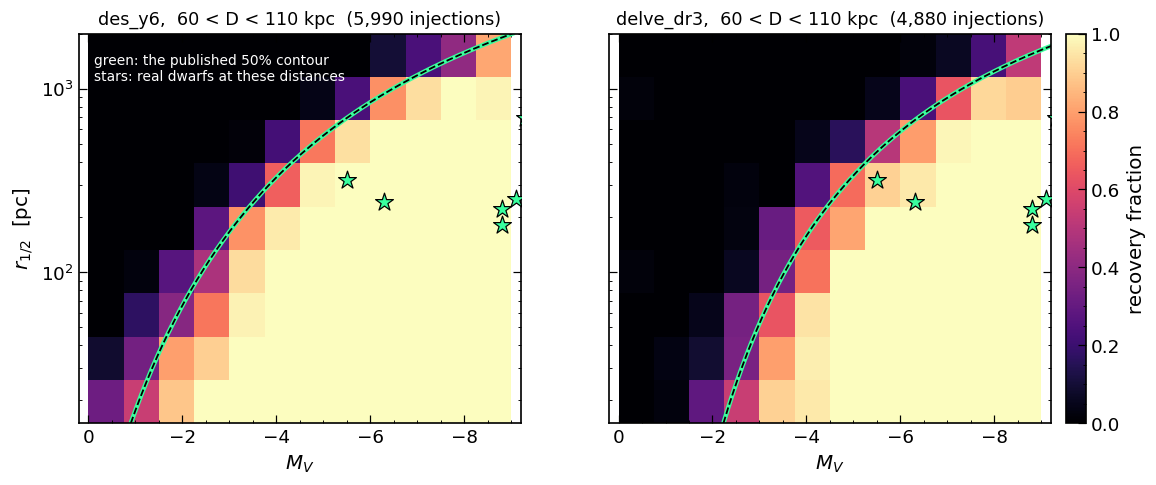

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True, sharex=True)

D_LO, D_HI = 60.0, 110.0                      # one octave of distance
D_MID = np.sqrt(D_LO * D_HI)
mv_edges = np.linspace(-9.0, 0.0, 13)
lr_edges = np.linspace(np.log10(15.0), np.log10(2000.0), 10)
rh = np.logspace(np.log10(15.0), np.log10(2000.0), 200)

for ax, survey in zip(axes, ("des_y6", "delve_dr3")):
    s = sims[(sims.survey == survey) & (sims.d_helio > D_LO) & (sims.d_helio < D_HI)]
    i = np.digitize(s.mv.values, mv_edges) - 1
    j = np.digitize(np.log10(s.rhalf.values), lr_edges) - 1
    ok = ((i >= 0) & (i < len(mv_edges) - 1) & (j >= 0) & (j < len(lr_edges) - 1))

    n = np.zeros((len(lr_edges) - 1, len(mv_edges) - 1))
    k = np.zeros_like(n)
    np.add.at(n, (j[ok], i[ok]), 1.0)
    np.add.at(k, (j[ok], i[ok]), s.detected.values[ok].astype(float))
    frac = np.where(n >= 20, k / np.maximum(n, 1), np.nan)

    cmap = plt.get_cmap("magma").with_extremes(bad="0.75")
    im = ax.pcolormesh(mv_edges, 10 ** lr_edges, frac, cmap=cmap, vmin=0, vmax=1,
                       shading="flat", rasterized=True)
    ax.plot(ref.census_p50_mv(rh, D_MID, survey=survey), rh, color="#39FF9E", lw=3.0)
    ax.plot(ref.census_p50_mv(rh, D_MID, survey=survey), rh, color="k", lw=1.2, ls="--")

    known = ref.mw_dwarfs()
    near = known[(known.d_helio > D_LO) & (known.d_helio < D_HI)]
    ax.scatter(near.mv, near.rhalf, s=150, marker="*", color="#39FF9E", edgecolor="k",
               lw=0.8, zorder=4)

    ax.set(yscale="log", xlim=(0.2, -9.2), ylim=(15, 2000), xlabel=r"$M_V$")
    ax.set_title(f"{survey},  {D_LO:.0f} < D < {D_HI:.0f} kpc  ({len(s):,} injections)",
                 fontsize=11.5)

axes[0].set_ylabel(r"$r_{1/2}$  [pc]")
cb = fig.colorbar(im, ax=axes, pad=0.015, fraction=0.035)
cb.set_label("recovery fraction")
axes[0].text(0.035, 0.95, "green: the published 50% contour\nstars: real dwarfs at these distances",
             transform=axes[0].transAxes, va="top", fontsize=9, color="w")

Most of what the Milky Way selection function is, is in this one figure.

**It is two-dimensional, and it has to be.** At $M_V=-4$ a 30 pc satellite is found nearly
always and a 1000 pc one essentially never — same luminosity, same distance, same survey.
Nothing written as $M_V < M_V^{\rm lim}(D)$ can express that, which is the entire reason
`assign_size` exists in this tutorial. It is also why Crater II, at $M_V=-8.2$, went undiscovered
until 2016: it is a kiloparsec across.

**The transition is not a step.** The recovery fraction slides from 1 to 0 over roughly a
magnitude.

**DES Y6 reaches 1.0–1.3 mag fainter than DELVE DR3**, although the imaging is comparable
($g\sim24.7$ against $24.2$). DELVE deliberately used a stricter detection threshold to keep
false positives down over a larger, more inhomogeneous footprint. A survey's purity requirement
is part of its selection function.

### The model we actually apply

Both census papers compress a figure like that into two lines. At fixed distance the 50%
detection locus in the $(M_V, r_{1/2})$ plane is

$$M_{V,50}(r_{1/2}, D) = M_{V,0}(D) + \frac{A_0(D)}{\log_{10}r_{1/2} - \log_{10}r_{1/2,0}(D)},$$

three numbers per distance per survey (`reference.census_p50_mv`), softened into a probability

$$P_{\rm det} = \mathrm{logistic}\!\left(\frac{M_{V,50}(r_{1/2}, D) - M_V}{w}\right)$$

with $w = 0.32$ mag for DES Y6 and $0.38$ for DELVE DR3. Those widths are not ours: they are
fitted to the same injections plotted above, and they live in `reference.CENSUS_WIDTH`. The width
turns out to matter very little — anything between 0.2 and 1.2 mag moves a predicted count by
under 3% — because the population is steep and most satellites sit far from the contour on one
side or the other.

In [3]:
print("M_V at 50% detection, by survey, size and distance\n")
print(f"{'':11s}{'D (kpc)':>9}" + "".join(f"{f'r={r} pc':>11}" for r in (30, 100, 300, 1000)))
for survey, _ in ref.MW_CENSUS_FOOTPRINT:
    for d in (25, 100, 300):
        print(f"{survey if d == 25 else '':11s}{d:9d}"
              + "".join(f"{ref.census_p50_mv(float(r), float(d), survey):11.2f}"
                        for r in (30, 100, 300, 1000)))

M_V at 50% detection, by survey, size and distance

             D (kpc)    r=30 pc   r=100 pc   r=300 pc  r=1000 pc
des_y6            25       0.10      -1.73      -4.34      -9.51
                 100      -1.80      -2.73      -3.99      -6.30
                 300      -3.59      -4.24      -5.13      -6.76
delve_dr3         25      -0.96      -2.56      -5.06     -10.99
                 100      -3.10      -3.95      -5.11      -7.26
                 300      -4.59      -5.14      -5.89      -7.27
ps1_dr1           25      -2.40      -4.11      -6.63     -11.87
                 100      -4.31      -5.17      -6.38      -8.74
                 300      -5.95      -6.49      -7.25      -8.71


Read that table across and it is the size dependence: at $D=100$ kpc DELVE reaches $M_V=-3.1$
for a 30 pc satellite and only $-7.3$ for a 1000 pc one. Read it down and it is the distance
dependence, ~2.5 mag from 25 to 300 kpc — which is *not* surface brightness dimming, since mean
surface brightness inside $r_{1/2}$ does not depend on distance at all. What fades is the number
of member stars above the survey's magnitude limit.

Read it between blocks and it is why "how deep is the survey" is the wrong question: PS1 is
2.4 mag shallower than DES Y6, and it still covers a quarter of the sky, so a whole-sky
prediction cannot leave it out.

---
## 5.2 Where they looked

Everything above answers "could this object have been found?". The other half of the selection
function answers "was anyone looking there?". The census does not cover the sky: it stitches
together three surveys, de-overlapped so each piece of sky belongs to exactly one of them, and
leaves the Galactic plane out entirely.

`io.load_census_footprint()` is the release's three nside = 4096 HEALPix masks (24 MB) averaged
onto 64,800 equal-area cells — 55 kB, no HEALPix library needed to read or index it, and each
survey's published area reproduced to 0.1%.

searched :   27,726 deg^2 = 67.2% of the sky
not      :   13,527 deg^2 = 32.8%  (mostly the Galactic plane)


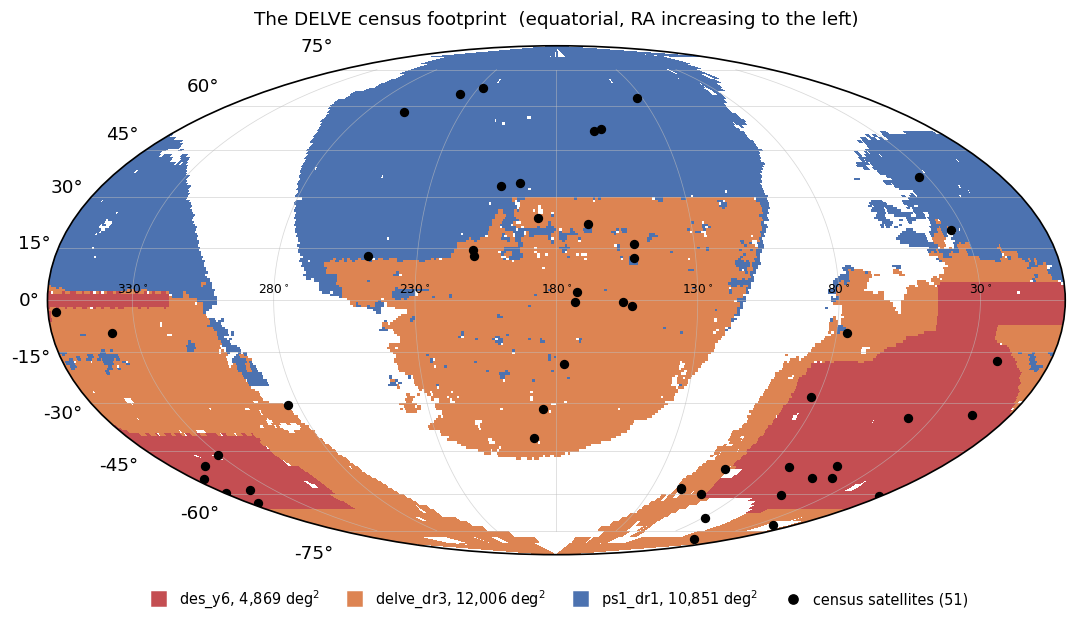

In [4]:
fig = plt.figure(figsize=(10.5, 5.6))
ax = fig.add_subplot(projection="mollweide")

areas = pl.plot_sky_coverage(ax, foot)
lon, lat = pl.sky_to_mollweide(obs.ra.values, obs.dec.values)
ax.scatter(lon, lat, s=26, color="k", zorder=5)
ax.set_title("The DELVE census footprint  (equatorial, RA increasing to the left)",
             fontsize=12, pad=14)

handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=pl.SURVEY_COLORS[s],
                      label=f"{s}, {areas[s]:,.0f} deg$^2$") for s in foot["surveys"]]
handles.append(plt.Line2D([], [], marker="o", ls="", ms=6, color="k",
                          label=f"census satellites ({len(obs)})"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.04),
          ncol=4, frameon=False, fontsize=9.5, columnspacing=1.4, handletextpad=0.4)
fig.tight_layout()

total = sum(areas.values())
print(f"searched : {total:8,.0f} deg^2 = {total/ref.SKY_AREA_DEG2:5.1%} of the sky")
print(f"not      : {ref.SKY_AREA_DEG2-total:8,.0f} deg^2 = {1-total/ref.SKY_AREA_DEG2:5.1%}"
      f"  (mostly the Galactic plane)")

The empty S-shaped band is the Milky Way's own disk, where the foreground star density and the
dust make a resolved-star search hopeless. Two thirds of the sky is searched; a third is not.

For a mock population that is a hard ceiling: however bright a satellite is, if it lands in the
unsearched third the census does not have it, so the footprint-averaged detection probability
can never exceed 0.67.

**That ceiling is wrong at the bright end.** Fornax, Sculptor and Draco were catalogued on
photographic plates decades before DES existed, and Tan+25's own reference list carries the LMC,
the SMC and Sagittarius attributed to no survey at all — they are in the sample because everyone
agrees they exist. So we treat the census as complete over the whole sky brighter than
$M_V=-8$ (`reference.CENSUS_BRIGHT_ALL_SKY_MV`).

That is a judgement call. Tan+25's own code makes the weaker assumption, all-sky only for
$M_V<-12.5$; $-8$ is the stronger and more common claim that nothing brighter than a classical
dwarf is still hiding, and it is only *nearly* true — Crater II (2016) and Antlia II (2019) are
both brighter than $-8$ and both were found this century, because they are enormous and diffuse
rather than faint.

And it comes with a bookkeeping obligation, which is this tutorial's thesis in miniature: **if
the mock is allowed to be all-sky complete brighter than $-8$, the observed sample has to count
the bright satellites found outside the footprint too.**

In [5]:
allg = pd.read_csv(os.path.join(io.OBS_DIR, "census_galaxies.csv"))
bright = allg[allg.in_box & (allg.mv < ref.CENSUS_BRIGHT_ALL_SKY_MV)]
extra = bright[~bright.in_census & bright.dwarf_class.isin(["D", "PD"])]

print(f"in the box and brighter than M_V = {ref.CENSUS_BRIGHT_ALL_SKY_MV}: {len(bright)} "
      f"satellites, {int(bright.in_census.sum())} of them inside the census footprint")
print(extra[["name", "mv", "d_gc", "survey", "in_census"]].to_string(index=False))

obs_cmp = pd.concat([obs, extra], ignore_index=True).sort_values("mv").reset_index(drop=True)
print(f"\ncomparison sample: {len(obs)} in the footprint + {len(extra)} bright outside "
      f"= {len(obs_cmp)}")

in the box and brighter than M_V = -8.0: 14 satellites, 13 of them inside the census footprint
     name    mv      d_gc survey  in_census
Antlia II -9.73 125.14882     gc      False

comparison sample: 51 in the footprint + 1 bright outside = 52


There is exactly one, and it is Antlia II — which sits behind the Galactic plane, and which Gaia
found in 2019.

---
# Section 6 — Running the forward model

`selection.mock_observe` chains everything: occupation and the SHMR, then $M_V$ and size, then
an observer inside the halo, then the aperture, then $P_{\rm det}$. A survey is a dictionary, so
that everything about it is visible in one place.

In [6]:
import pprint
pprint.pprint(sl.MW_SURVEY, sort_dicts=False)

{'geometry': 'mw',
 'aperture': {'r_max_kpc': 400.0},
 'selection': {'kind': 'census',
               'width': None,
               'use_sky': True,
               'bright_all_sky_mv': -8.0},
 'requires_mv': True}


`use_sky=True` looks each satellite up in the real mask above rather than multiplying by the
footprint area fraction. That needs sky positions, and `place_mw_observer` supplies them — but
read what they mean. These SatGen runs have `fd = fb = 0`: **no disk and no bulge, so the halo
has no preferred plane**, and there is no physically meaningful place to put the Sun, let alone
a correct direction for the Galactic centre. Each host's sky is therefore rotated by its own
*random* rotation before being written down in RA and Dec.

So the positions are not predictions of where these satellites would be. What they buy is the
scatter: averaged over many realizations the masked version gives the same mean as the area
fraction, but a single realization sees a footprint with a jagged edge and a hole in the middle.

In [29]:
hosts = io.load_hosts(data_dir="../data/", prefix="satgen_new_MW")
subs  = io.load_subhalos(data_dir="../data/", prefix="satgen_new_MW")

LGM_MW, DLGM = 12.0, 0.05                 # Milky-Way-mass hosts, +-0.05 dex
hh = hosts[np.abs(hosts.host_lgmvir - LGM_MW) <= DLGM + 1e-9]
sub_mw = subs[subs.host_id.isin(hh.host_id)]

FIDUCIAL = dict(
    occupation_params=dict(logM50=8.0, sigma_gal=0.4),
    shmr_params=dict(alpha=2.3, logM0=10.0, logMstar0=6.5, sigma_logMstar=0.3),
    observable_params=dict(
        mass_to_light=dict(mass_to_light_v=1.5, sigma_log_ml=0.0, 
                           mass_to_light_bright=1.0, mv_split=-10.0,),
        size=dict(size_norm=1500.0, size_slope=1.0, sigma_log_size=0.2, rvir_pivot=100.0)),
)

BOX = ref.TAN25_BOX
def in_tan25_box(df):
    # Cut a mock catalog to Tan+25's stated analysis box, exactly as they state it.
    return df[(df.mv >= BOX["mv"][0]) & (df.mv <= BOX["mv"][1])
              & (df.rhalf >= BOX["rhalf"][0]) & (df.rhalf <= BOX["rhalf"][1])
              & (df.r_3d >= BOX["d_gc"][0]) & (df.r_3d <= BOX["d_gc"][1])]

N_OBSERVER = 10
frames = []
for r in range(N_OBSERVER):
    out = sl.mock_observe(sub_mw, survey_params=sl.MW_SURVEY,
                          rng=np.random.default_rng(SEED + r),
                          detected_only=False, **FIDUCIAL)
    out = in_tan25_box(out).copy()
    out["realization"] = r
    frames.append(out)

mock = pd.concat(frames, ignore_index=True)
KEY = ["realization", "host_id"]
n_real = mock.groupby(KEY).ngroups
n_intr = mock.groupby(KEY).size()
n_det  = mock.groupby(KEY).p_det.sum()

print(f"{n_real} mock Milky Ways ({len(hh)} hosts x {N_OBSERVER} observer placements)\n")
print(f"per mock Milky Way, inside the Tan+25 box:")
print(f"   intrinsic population : {n_intr.median():6.1f}  "
      f"[{n_intr.quantile(.16):.0f}, {n_intr.quantile(.84):.0f}]")
print(f"   census-detected      : {n_det.median():6.1f}  "
      f"[{n_det.quantile(.16):.1f}, {n_det.quantile(.84):.1f}]"
      f"   -> the mock's own completeness {n_det.median()/n_intr.median():.0%}")
print(f"\nTan+25 completeness-corrected total : {np.median(chain[:,5]):.0f} "
      f"[{np.percentile(chain[:,5],16):.0f}, {np.percentile(chain[:,5],84):.0f}]")
print(f"comparison sample                   : {len(obs_cmp)}")

330 mock Milky Ways (33 hosts x 10 observer placements)

per mock Milky Way, inside the Tan+25 box:
   intrinsic population :  295.0  [266, 324]
   census-detected      :   56.2  [48.9, 64.3]   -> the mock's own completeness 19%

Tan+25 completeness-corrected total : 286 [228, 360]
comparison sample                   : 52


Two choices in that cell are worth naming. **`detected_only=False`** returns the full table with
`p_det` attached, so the intrinsic and observed populations are the same rows from the same
random draw — any difference between the curves below is the selection function and nothing
else. And we **sum `p_det`** rather than counting `detected`: the expected number of detections
is the same thing in the mean and much less noisy than a coin flip per satellite.

Before the comparison, one measurement that justifies the two modelling choices above.

In [30]:
p_area = sl.census_detection_probability(mock.mv.values, mock.rhalf.values, mock.d_helio.values)
p_sky  = sl.census_detection_probability(mock.mv.values, mock.rhalf.values, mock.d_helio.values,
                                         ra=mock.ra.values, dec=mock.dec.values)
key = [mock.realization.values, mock.host_id.values]

print(f"{'':<26}{'median N_det':>13}{'16-84%':>16}{'scatter':>10}")
for lab, p in [("footprint area only", p_area), ("+ real sky mask", p_sky),
               ("+ all-sky above M_V=-8", mock.p_det.values)]:
    t = pd.Series(p).groupby(key).sum()
    print(f"{lab:<26}{t.median():13.1f}"
          f"{f'[{t.quantile(.16):.1f}, {t.quantile(.84):.1f}]':>16}{t.std():10.2f}")

                           median N_det          16-84%   scatter
footprint area only                50.9    [45.6, 57.3]      5.70
+ real sky mask                    50.6    [43.7, 58.8]      7.70
+ all-sky above M_V=-8             56.2    [48.9, 64.3]      8.12


The mask moves the **mean** by 0.3% — as it must, since a random rotation of an isotropic
population against a fixed footprint averages to the area fraction exactly — and the **scatter**
by a third. That is not a rounding error when the question is whether one observed number is
consistent with a model, because that question is only about the width of the predicted
distribution. The bright-end assumption adds about six detections, all of them at $M_V<-8$.

---
## 6.1 The predicted luminosity function

The point of the whole exercise, drawn twice. On the left the mock's **intrinsic** population
against Tan+25's **completeness-corrected** model — a test of the galaxy–halo model with no
selection function on either side. On the right the mock's **detected** population against the
satellites the census actually has.

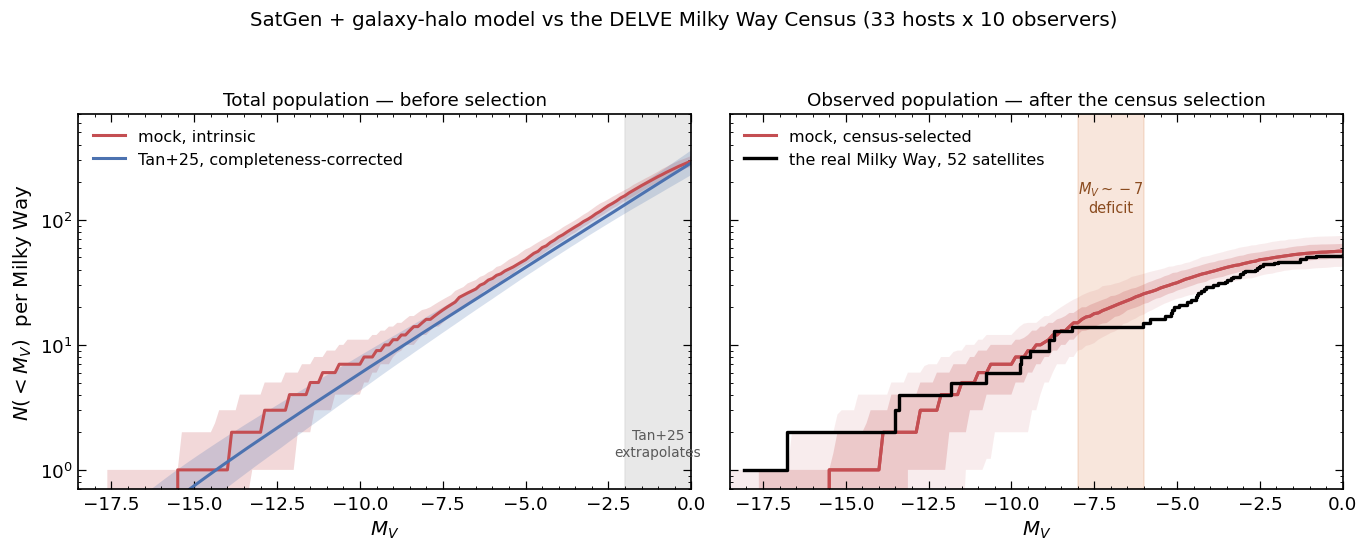

In [31]:
grid = np.linspace(-20.0, 0.0, 161)

def cumulative(col, grid, weight=None):
    # N(< grid) for every mock Milky Way, shape (n_real, len(grid)).
    out = np.zeros((n_real, len(grid)))
    for i, (_, g) in enumerate(mock.groupby(KEY, sort=True)):
        v = g[col].to_numpy()
        order = np.argsort(v)
        w = np.ones(len(g)) if weight is None else g[weight].to_numpy()
        cw = np.concatenate([[0.0], np.cumsum(w[order])])
        out[i] = cw[np.searchsorted(v[order], grid)]
    return out

cum_intr = cumulative("mv", grid)
cum_det  = cumulative("mv", grid, weight="p_det")
cum_tan  = ref.tan25_luminosity_function(grid, chain)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.1), sharey=True)

ax = axes[0]
pl.plot_band(ax, grid, cum_intr, color=C_MOCK, label="mock, intrinsic")
pl.plot_band(ax, grid, cum_tan, color=C_TAN, label="Tan+25, completeness-corrected")
ax.axvspan(-2, 0, color="0.85", alpha=0.6, zorder=0)
ax.text(-1.0, 1.3, "Tan+25\nextrapolates", fontsize=9, ha="center", color="0.35")
ax.set_title("Total population — before selection", fontsize=12)
ax.set_ylabel(r"$N(<M_V)$  per Milky Way")
ax.legend(loc="upper left")

ax = axes[1]
pl.plot_band(ax, grid, cum_det, color=C_MOCK, label="mock, census-selected", percentiles=(2.5, 50, 97.5), alpha=0.1)
pl.plot_band(ax, grid, cum_det, color=C_MOCK, percentiles=(16, 50, 84),)
ax.step(np.sort(obs_cmp.mv.values), np.arange(1, len(obs_cmp) + 1), where="post",
        color=C_OBS, lw=2.2, label=f"the real Milky Way, {len(obs_cmp)} satellites")
ax.axvspan(-8, -6, color="#DD8452", alpha=0.20, zorder=0)
ax.text(-7.0, 115, r"$M_V\sim-7$" + "\ndeficit", fontsize=9.5, ha="center", color="#8a4b1f")
ax.set_title("Observed population — after the census selection", fontsize=12)
ax.legend(loc="upper left")

for ax in axes:
    ax.set(yscale="log", xlim=(-18.5, 0), ylim=(0.7, 700), xlabel=r"$M_V$")
fig.suptitle(f"SatGen + galaxy-halo model vs the DELVE Milky Way Census "
             f"({len(hh)} hosts x {N_OBSERVER} observers)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])

In [32]:
mv_grid = np.array([-8.0, -6.0, -4.0, -2.0, 0.0])
q_tan = ref.tan25_lf_quantiles(mv_grid, chain)

print("Cumulative luminosity function  N(< M_V), inside the Tan+25 box\n")
print(f"{'M_V':>5} | {'mock intrinsic':^22} {'Tan+25 corrected':^22} {'ratio':>6} |"
      f" {'mock detected':^22} {'obs':>4} {'ratio':>6}")
print("-" * 100)
for j, mvc in enumerate(mv_grid):
    s = mock[mock.mv <= mvc]
    ni = s.groupby(KEY).size().reindex(n_intr.index, fill_value=0)
    nd = s.groupby(KEY).p_det.sum().reindex(n_intr.index, fill_value=0.0)
    nobs = int((obs_cmp.mv <= mvc).sum())
    print(f"{mvc:5.0f} | {ni.median():6.1f} [{ni.quantile(.16):5.1f},{ni.quantile(.84):6.1f}] "
          f"{q_tan[1,j]:6.1f} [{q_tan[0,j]:5.1f},{q_tan[2,j]:6.1f}] {ni.median()/q_tan[1,j]:6.2f} |"
          f" {nd.median():6.1f} [{nd.quantile(.16):5.1f},{nd.quantile(.84):6.1f}] "
          f"{nobs:4d} {nd.median()/max(nobs,1):6.2f}")

frac_faint = 1.0 - np.median(ref.tan25_luminosity_function([-2.0], chain)) / np.median(chain[:, 5])
print(f"\nfraction of Tan+25's headline total fainter than M_V = -2 : {frac_faint:.0%}")
print(f"census satellites fainter than M_V = -2                   : "
      f"{int((obs_cmp.mv > -2).sum())}")

Cumulative luminosity function  N(< M_V), inside the Tan+25 box

  M_V |     mock intrinsic        Tan+25 corrected     ratio |     mock detected       obs  ratio
----------------------------------------------------------------------------------------------------
   -8 |   16.0 [ 12.0,  19.4]   13.0 [ 10.1,  16.7]   1.23 |   15.0 [ 12.0,  19.0]   14   1.07
   -6 |   34.0 [ 29.0,  39.4]   28.2 [ 23.3,  33.9]   1.20 |   25.7 [ 21.3,  30.4]   15   1.71
   -4 |   73.0 [ 65.0,  82.4]   61.3 [ 52.4,  70.9]   1.19 |   38.3 [ 33.3,  45.4]   29   1.32
   -2 |  156.0 [141.6, 173.4]  132.3 [112.1, 156.3]   1.18 |   50.3 [ 43.7,  58.0]   45   1.12
    0 |  295.0 [266.0, 324.4]  285.5 [227.9, 359.7]   1.03 |   56.2 [ 48.9,  64.3]   52   1.08

fraction of Tan+25's headline total fainter than M_V = -2 : 54%
census satellites fainter than M_V = -2                   : 7


**The last row of the left half is a trap, and the column of ratios shows why.** Against the
completeness-corrected model the mock is high by a steady 1.4–1.9 at every magnitude the census
actually probes, and then the ratio drops to 1.2 at $M_V=0$. That is not the model becoming
right. It is Tan+25's power law climbing steeply through the two magnitudes where the census
detects almost nothing, until it catches up with the mock.

More than half of their headline number lies there. "$265^{+79}_{-47}$ satellites" is a
statement about a box that runs to $M_V=0$, and the census has seven objects fainter than $-2$.
That is not a criticism of their analysis — the extrapolation is the *point* of fitting a
population model, and their error bar is honest about it. It is a warning about how to use the
number.

> A single-threshold comparison can agree while the underlying luminosity functions disagree by
> a factor of two. Compare distributions, bin by bin, inside a box both sides share.

## 6.2 Where the excess lives

A 70% excess spread evenly over the luminosity function would be one kind of problem. This one
is not spread evenly.

In [33]:
edges = [-20, -8, -6, -4, -2, 0.01]
print(f"{'M_V bin':>13} | {'mock detected':^22} | {'observed':>8} | {'frac of mocks <= obs':>21}")
print("-" * 74)
for lo, hi in zip(edges[:-1], edges[1:]):
    s = mock[(mock.mv >= lo) & (mock.mv < hi)]
    nd = s.groupby(KEY).p_det.sum().reindex(n_intr.index, fill_value=0.0)
    nobs = int(((obs_cmp.mv >= lo) & (obs_cmp.mv < hi)).sum())
    flag = "   <---" if (nd <= nobs).mean() < 0.02 else ""
    print(f"[{lo:5.0f},{hi:4.0f}) | {nd.median():6.1f} [{nd.quantile(.16):5.1f},"
          f"{nd.quantile(.84):6.1f}] | {nobs:8d} | {(nd <= nobs).mean():21.2f}{flag}")

      M_V bin |     mock detected      | observed |  frac of mocks <= obs
--------------------------------------------------------------------------
[  -20,  -8) |   15.0 [ 12.0,  19.0] |       14 |                  0.39
[   -8,  -6) |   10.1 [  7.2,  13.2] |        1 |                  0.00   <---
[   -6,  -4) |   12.9 [  9.7,  16.5] |       14 |                  0.62
[   -4,  -2) |   11.7 [  8.8,  15.5] |       16 |                  0.87
[   -2,   0) |    5.4 [  3.3,   7.7] |        7 |                  0.76


Outside one bin the mock is high by factors of 1.0 to 1.6, the kind of residual most of the
model's own knobs could absorb. Inside it — at $-8 \le M_V < -6$ — the mock predicts ~14
detectable satellites and the Milky Way has **one**, Boötes I. Not one of the 330 mock Milky Ways
gets that low, and moving the bin edges around does not soften it.

This is **not our discovery**. Tan et al. report the same feature against their own smooth
empirical model:

> *"We also observe a deficit of galaxies with absolute magnitude $M_V \sim -7$ compared to the
> predictions of our empirical model. This feature has been noted by [Bose et al. 2018], who
> attribute it to a bimodality in the satellite population driven by the effects of
> reionization."*

Which is the part that matters. Two independent smooth models — theirs fit to the data, ours
built from a subhalo catalog and a galaxy–halo relation — land in the same place, and the real
Milky Way does not. **A smooth galaxy–halo model cannot produce a gap.** $M_{50}$, $\alpha$,
$\sigma_{\log M_\star}$ and the size normalization all move the luminosity function smoothly, so
any of them could absorb the overall factor of ~1.7 and none of them can absorb this.

---
## 6.3 The radial distribution

The other thing the census constrains is *where* the satellites are, and it is worth a look for
one specific reason: **it is a shape, so the normalization we have been arguing about divides
out.** A model can be wrong about how many satellites there are and still right about where they
sit. Tan+25 fit a cored profile,
$\mathrm{d}N/\mathrm{d}D \propto D^2 (D + r_{\rm core})^{-3}$, so the same two comparisons work
in $D_{\rm GC}$.

    D_GC  mock intr   Tan+25  mock det  observed
      50       0.31     0.17      0.38      0.35
     100       0.56     0.40      0.67      0.63
     150       0.72     0.59      0.81      0.87


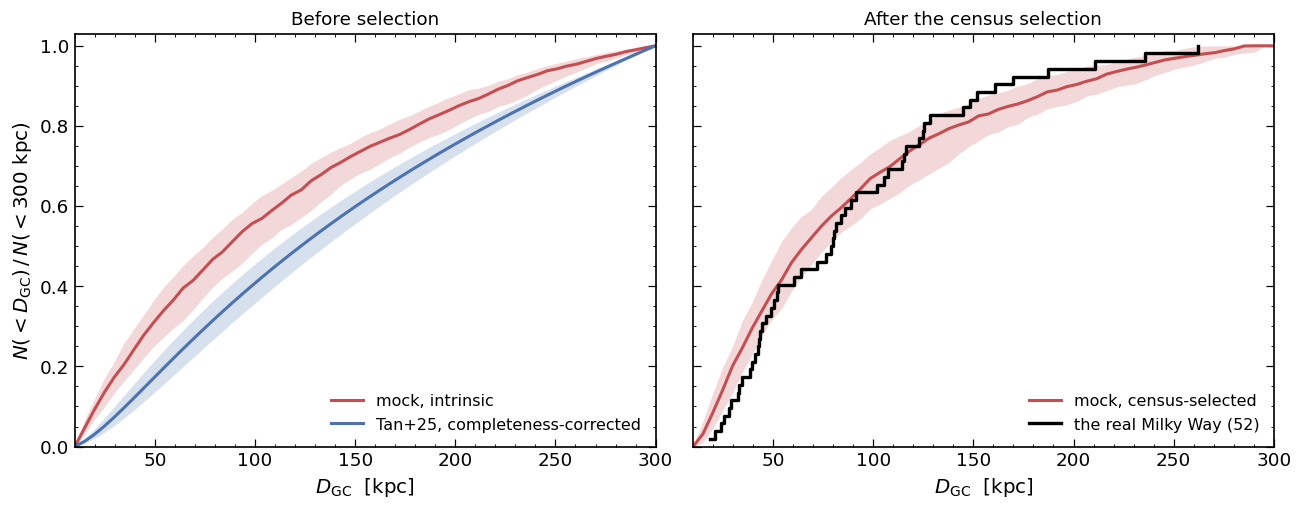

In [28]:
r_grid = np.linspace(10.0, 300.0, 60)

def shape(counts):
    return counts / counts[:, -1:]          # normalize each realization to its own total

prof_intr = shape(cumulative("r_3d", r_grid))
prof_det  = shape(cumulative("r_3d", r_grid, weight="p_det"))
prof_tan  = shape(ref.tan25_radial_profile(r_grid, chain))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)

ax = axes[0]
pl.plot_band(ax, r_grid, prof_intr, color=C_MOCK, label="mock, intrinsic")
pl.plot_band(ax, r_grid, prof_tan, color=C_TAN, label="Tan+25, completeness-corrected")
ax.set_title("Before selection", fontsize=12)
ax.set_ylabel(r"$N(<D_{\rm GC})\,/\,N(<300\ {\rm kpc})$")
ax.legend(loc="lower right")

ax = axes[1]
pl.plot_band(ax, r_grid, prof_det, color=C_MOCK, label="mock, census-selected")
d_sorted = np.sort(obs_cmp.d_gc.values)
ax.step(d_sorted, np.arange(1, len(d_sorted) + 1) / len(d_sorted), where="post",
        color=C_OBS, lw=2.2, label=f"the real Milky Way ({len(obs_cmp)})")
ax.set_title("After the census selection", fontsize=12)
ax.legend(loc="lower right")

for ax in axes:
    ax.set(xlim=(10, 300), ylim=(0, 1.03), xlabel=r"$D_{\rm GC}$  [kpc]")
fig.tight_layout()

print(f"{'D_GC':>8}{'mock intr':>11}{'Tan+25':>9}{'mock det':>10}{'observed':>10}")
for r in (50.0, 100.0, 150.0):
    k = np.argmin(abs(r_grid - r))
    print(f"{r:8.0f}{np.median(prof_intr[:, k]):11.2f}{np.median(prof_tan[:, k]):9.2f}"
          f"{np.median(prof_det[:, k]):10.2f}{(obs_cmp.d_gc < r).mean():10.2f}")

The right panel is the best agreement in this notebook, and it did not have to come out that
way: a model that gets the abundance wrong by 70% gets the shape right, within the
realization-to-realization scatter, over the whole range.

Some of that is built by the selection function rather than by the physics, as the left panel
shows — distance is the strongest single variable in $P_{\rm det}$, so selection pulls the
detected profile inward hard. Inside 50 kpc the mock holds 32% of its intrinsic satellites but
41% of its detected ones.

The left panel is the more interesting disagreement. **The mock's intrinsic population is more
centrally concentrated than Tan+25's completeness-corrected profile** — 56% of its satellites
inside 100 kpc against their 40%. Either the SatGen satellites really are too concentrated, or
the correction is over-extended in the outer bins, where a strongly distance-dependent selection
function is being divided out of a sample of 51. Nothing here separates the two, and the
*observed* comparison on the right is the one carrying weight, because it applies the same
selection to both sides.

---
## 6.4 What this comparison is still getting wrong

The mock over-predicts the census by a factor of about 1.7 and its satellites are too centrally
concentrated. Before blaming either on dark matter, the list of everything else that could
produce those two numbers, in rough order of how much it matters.

**1. The simulated halo has no disk.** These SatGen runs have `fd = fb = 0`, so a satellite
passing through the inner tens of kpc feels no disk shock. Simulations that add a disk potential
destroy a large fraction of the inner subhalos — [D'Onghia et al.
2010](https://arxiv.org/abs/0907.3482), [Garrison-Kimmel et al.
2017](https://arxiv.org/abs/1701.03792), [Kelley et al. 2019](https://arxiv.org/abs/1811.12413)
— concentrated inside ~30–50 kpc. That one missing ingredient points the right way for *both*
residuals: it would remove satellites, and remove them preferentially from the centre. It is
also not a knob in the galaxy–halo model.

**2. The Milky Way's halo mass.** We picked $\log M_{\rm vir}=12.0\pm0.05$, a Bryan & Norman
virial mass, so $\log M_{200c}\approx11.94$ — comfortably inside the dynamical range. But
satellite counts scale nearly linearly with host mass, and that range is wide.

**3. Isotropy.** The mock's satellites are isotropic because a halo with no disk has no preferred
plane. The real ones crowd into the deep southern sky, an anisotropy Tan+25 detect at
$\sim2\sigma$ and attribute to the Magellanic system. Applied to the known dwarfs our
footprint-averaged model expects 39 census recoveries against the 49 they got — so it is ~25%
*pessimistic* for the real population, and correcting it would push the mock further above the
census, not closer. It cannot explain the excess away.

**4. What we left out of the release.** The trained classifiers carry the foreground stellar
density within a field, worth ~0.2 mag against a 0.35 mag softening width; they need `xgboost`
and are the right tool for an actual inference. Our reduced footprint reproduces the areas to
0.1% but cannot say whether one particular object fell in a sub-degree hole.

**5. What the mock does not have.** No membership problem, no distance errors, no ambiguity
about what counts as a galaxy. The real sample has all three: seven of the 51 are "probable"
dwarfs, one more is ambiguous enough that Tan+25 drop it, and the star-cluster/galaxy boundary is
argued over object by object. A few either way is small against 51 and large against the seven
satellites fainter than $M_V=-2$.

And the model's own parameters are simply fixed here at the Part 1 fiducials. Point 2 is the one
that is cheap to check, so check it.

In [13]:
rows = []
for lgm in (11.6, 11.8, 12.0, 12.2, 12.4):
    ids = hosts[np.abs(hosts.host_lgmvir - lgm) <= 0.051].host_id
    sub = subs[subs.host_id.isin(ids)]
    tot = []
    for r in range(5):
        m = sl.mock_observe(sub, survey_params=sl.MW_SURVEY,
                            rng=np.random.default_rng(SEED + r),
                            detected_only=False, **FIDUCIAL)
        m = in_tan25_box(m)
        tot.append(m.groupby("host_id").p_det.sum().reindex(ids).fillna(0.0).to_numpy())
    tot = np.concatenate(tot)
    rows.append((lgm, np.median(tot)))
    print(f"log Mvir = {lgm:.1f} :  {np.median(tot):5.1f} detected  "
          f"[{np.percentile(tot,16):.1f}, {np.percentile(tot,84):.1f}]   vs {len(obs_cmp)} observed")

lgms = np.array([r[0] for r in rows]); nd = np.array([r[1] for r in rows])
slope, icpt = np.polyfit(lgms, np.log10(nd), 1)
need = (np.log10(len(obs_cmp)) - icpt) / slope
print(f"\nN_detected ~ Mvir^{slope:.2f};  matching {len(obs_cmp)} would need "
      f"log Mvir = {need:.2f}, i.e. log M200c = {need-0.06:.2f}")

log Mvir = 11.6 :   25.2 detected  [20.2, 30.5]   vs 52 observed
log Mvir = 11.8 :   36.1 detected  [30.4, 42.6]   vs 52 observed
log Mvir = 12.0 :   55.5 detected  [47.2, 62.9]   vs 52 observed


log Mvir = 12.2 :   85.0 detected  [71.4, 97.7]   vs 52 observed
log Mvir = 12.4 :  121.0 detected  [105.6, 135.3]   vs 52 observed

N_detected ~ Mvir^0.87;  matching 52 would need log Mvir = 11.97, i.e. log M200c = 11.91


Nearly linear, as it should be. So the excess *could* be absorbed by a lighter Milky Way — but
only by one lighter than the dynamical measurements allow, and doing so would change nothing
about the $M_V\sim-7$ gap. That is the pattern to watch for: **a normalization residual has many
possible explanations and a shape residual has very few.**

---
## Exercises

```python
# TRY IT: the excess is ~1.7x. Which knob can absorb it, and which cannot?
```

Re-run the mock with each of these in turn, then re-make the bin table in §6.2:
`logM50 = 8.5` (fewer low-mass halos light up), `alpha = 2.3` (steeper SHMR, faint satellites
get fainter), `size_norm = 3000.0` (double the sizes, halve the surface brightness). For each,
ask two questions: does the *total* detected count come down to 52, and does the
$-8 \le M_V < -6$ bin come down to 1? The first should be easy for all three; the second should
be impossible for all three, and understanding why is the point.

```python
# TRY IT: what do the sky mask and the bright-end assumption actually change?
```

Swap `sl.MW_SURVEY` for `sl.MW_SURVEY_ISOTROPIC` — same contour, no mask, no bright-end
assumption — and re-make the §6.1 figure. Which moves: the median, the band, or both? Then ask
which of the two the observed count is really being compared against.

---
## Summary

| | result |
|---|---|
| completeness | measured from 59,150 injections; two-dimensional in $(M_V, r_{1/2})$ at every distance |
| footprint | 27,700 deg², 67% of the sky, no census in the Galactic plane |
| bright end | all-sky above $M_V=-8$ — and then the data side must count Antlia II too |
| sky mask vs area fraction | same mean to 0.3%, **33% more scatter** |
| mock vs corrected LF | **1.4–1.9× high** where the census constrains; 1.2 only via extrapolation |
| mock vs observed LF | high by 1.7×, a third of it in one magnitude bin |
| $-8 \le M_V < -6$ | mock ~14, Milky Way 1, in 0 of 330 mock Milky Ways |
| radial shape | agrees after selection; mock too concentrated before it |

> Compare distributions, not totals, inside a box both sides share, with the same selection
> function applied to both. A single-threshold comparison agreed to 20% here while the underlying
> luminosity functions disagreed by nearly a factor of two.

> Every knob in a galaxy–halo model moves the luminosity function *smoothly*. The one feature the
> Milky Way shows that our model does not is a **gap** — the kind of residual no nuisance
> parameter can absorb, and therefore the kind worth chasing.